### Авторегрессия (AR-модель)
$$
y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t
$$

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import warnings

from statsmodels.tsa.stattools import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

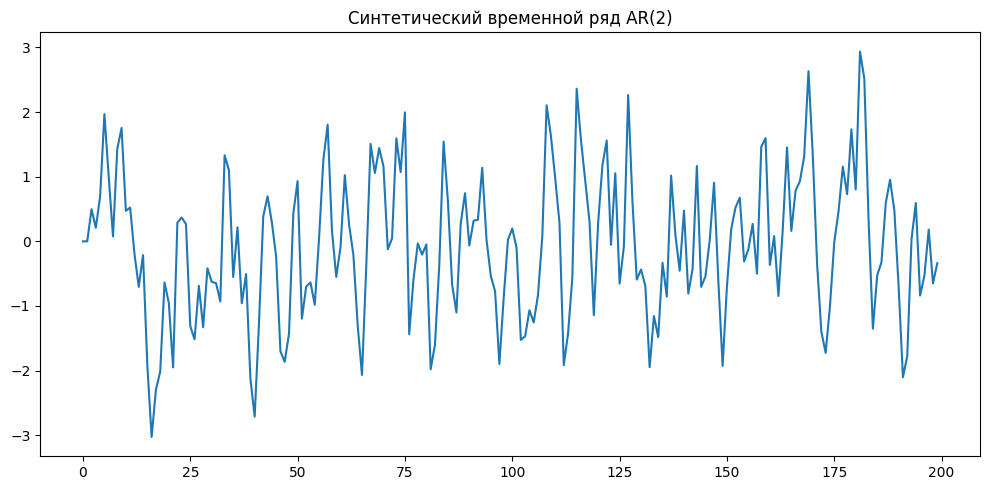

In [2]:
# Синтетические данные для AR(2):
np.random.seed(42)
n = 200
y = np.zeros(n)
for t in range(2, n):
    y[t] = 0.7*y[t-1] - 0.2*y[t-2] + np.random.normal(scale=1)

plt.figure(figsize=(10,5))
plt.plot(y)
plt.title("Синтетический временной ряд AR(2)")
plt.tight_layout()
plt.show()

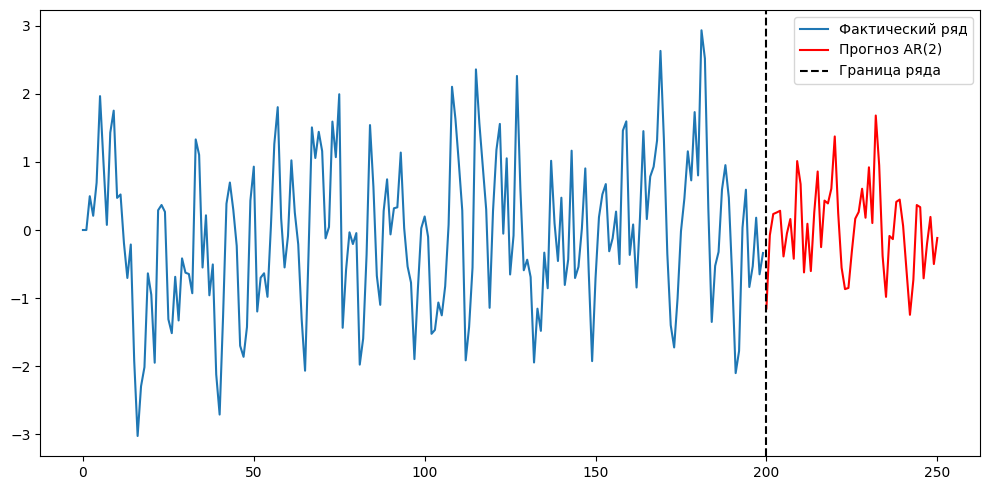

In [13]:
# Обучение AR-модели:
model_ar = sm.tsa.ARIMA(y, order=(2,0,0)).fit()

# Прогноз:
borders = {'start': 150, 'end': 200}
pred_ar = model_ar.predict(start=borders['start'], end=borders['end'])
plt.figure(figsize=(10,5))
plt.plot(y, label="Фактический ряд")
plt.plot(range(borders['start'] + 50, borders['end'] + 51), pred_ar, label="Прогноз AR(2)", color="red")
plt.axvline(x=borders['end'], color='black', linestyle='--', label='Граница ряда')
plt.legend()
plt.tight_layout()
plt.show()

### Скользящее среднее (MA-модель)
$$
y_t = c + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \cdots + \theta_q \varepsilon_{t-q} + \varepsilon_t
$$

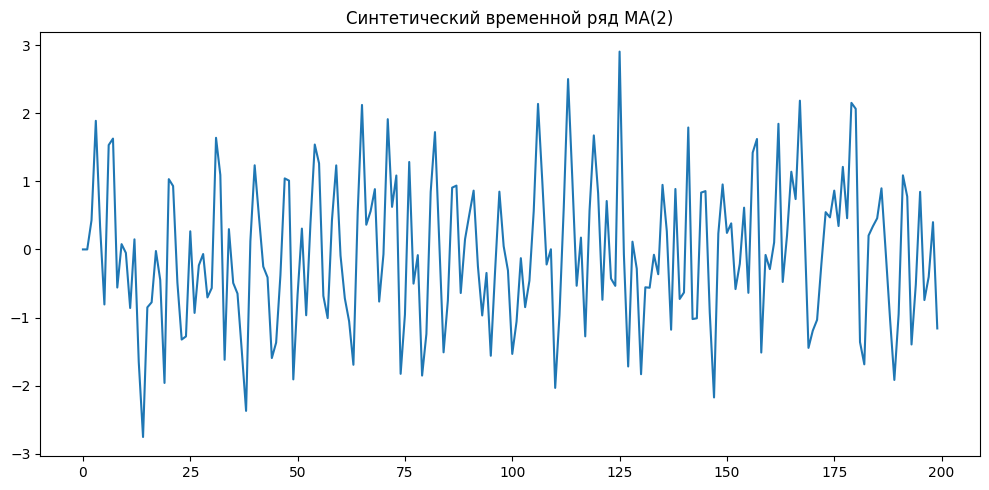

In [14]:
# Синтетические данные для MA(2):
np.random.seed(42)
n = 200
eps = np.random.normal(scale=1, size=n)
y = np.zeros(n)
for t in range(2, n):
    y[t] = eps[t] + 0.5*eps[t-1] - 0.3*eps[t-2]

plt.figure(figsize=(10,5))
plt.plot(y)
plt.title("Синтетический временной ряд MA(2)")
plt.tight_layout()
plt.show()

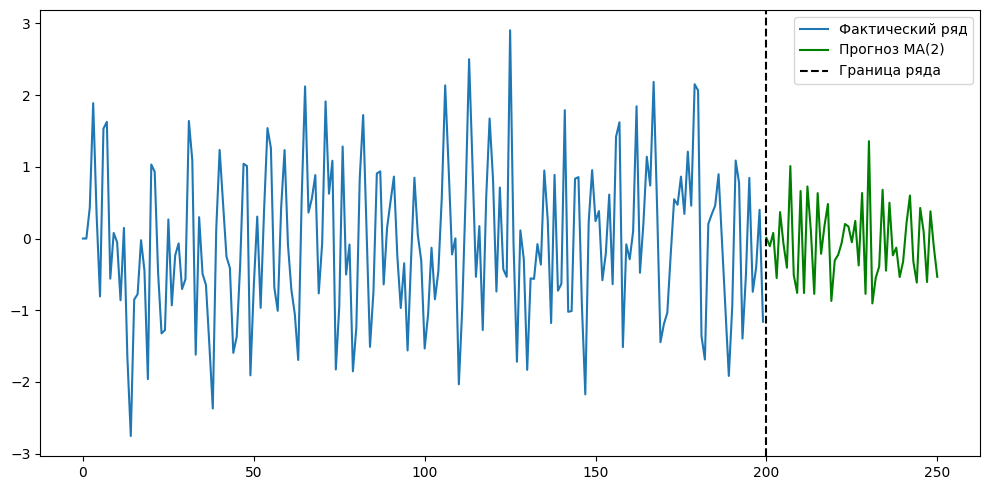

In [15]:
# Обучение MA-модели:
model_ma = sm.tsa.ARIMA(y, order=(0,0,2)).fit()

# Прогноз:
pred_ma = model_ma.predict(start=borders['start'], end=borders['end'])
plt.figure(figsize=(10,5))
plt.plot(y, label="Фактический ряд")
plt.plot(range(borders['start'] + 50, borders['end'] + 51), pred_ma, label="Прогноз MA(2)", color="green")
plt.axvline(x=borders['end'], color='black', linestyle='--', label='Граница ряда')
plt.legend()
plt.tight_layout()
plt.show()

### ARMA-модель
$$
y_t = c + \phi_1 y_{t-1} + \cdots + \phi_p y_{t-p} + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q} + \varepsilon_t
$$

### ACF, PACF

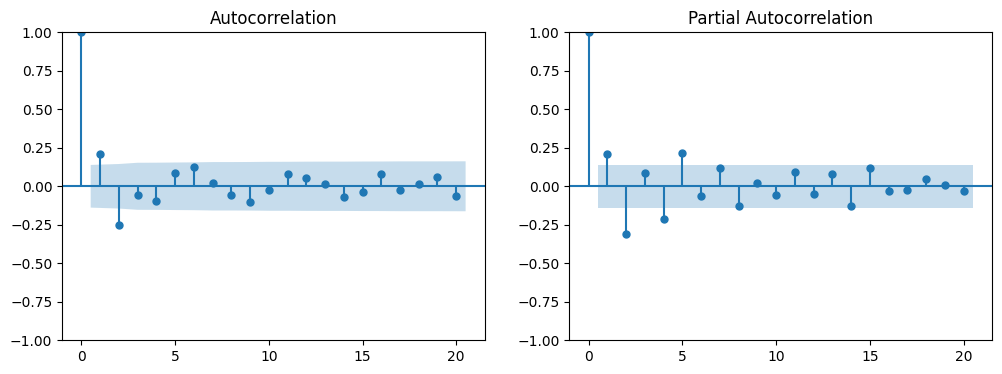

In [17]:
# Построим ACF и PACF для AR(2)
fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(y, lags=20, ax=axes[0])
plot_pacf(y, lags=20, ax=axes[1])
plt.show()

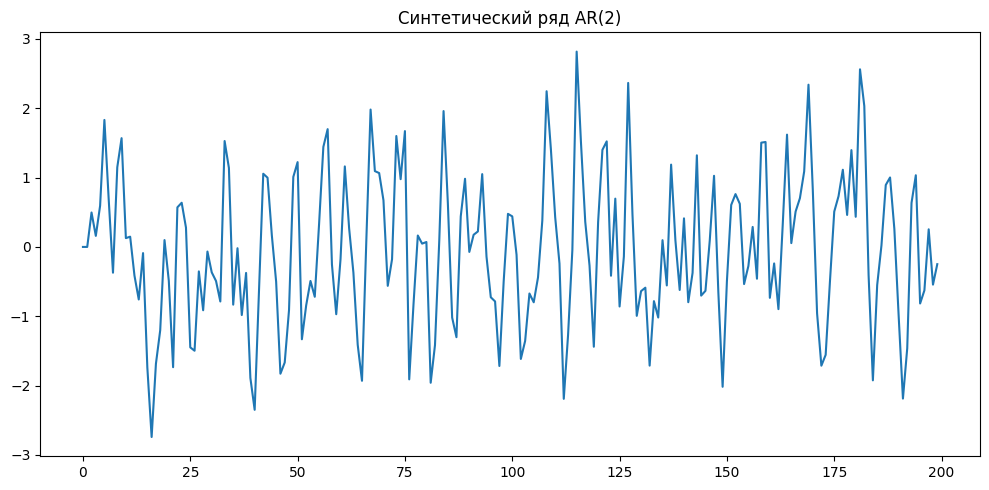

In [18]:
np.random.seed(42)
n = 200
y = np.zeros(n)
for t in range(2, n):
    y[t] = 0.6*y[t-1] - 0.3*y[t-2] + np.random.normal()

plt.figure(figsize=(10,5))
plt.plot(y)
plt.title("Синтетический ряд AR(2)")
plt.tight_layout()
plt.show()

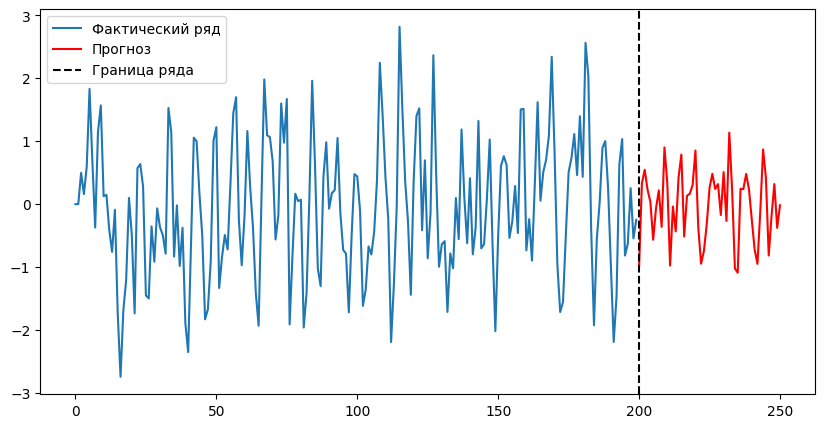

In [23]:
model = sm.tsa.ARIMA(y, order=(2,0,1)).fit()

pred = model.predict(start=borders['start'], end=borders['end'])
plt.figure(figsize=(10,5))
plt.plot(y, label="Фактический ряд")
plt.plot(range(borders['start'] + 50, borders['end'] + 51), pred, label="Прогноз", color="red")
plt.axvline(x=borders['end'], color='black', linestyle='--', label='Граница ряда')
plt.legend()
plt.show()

### ARIMA

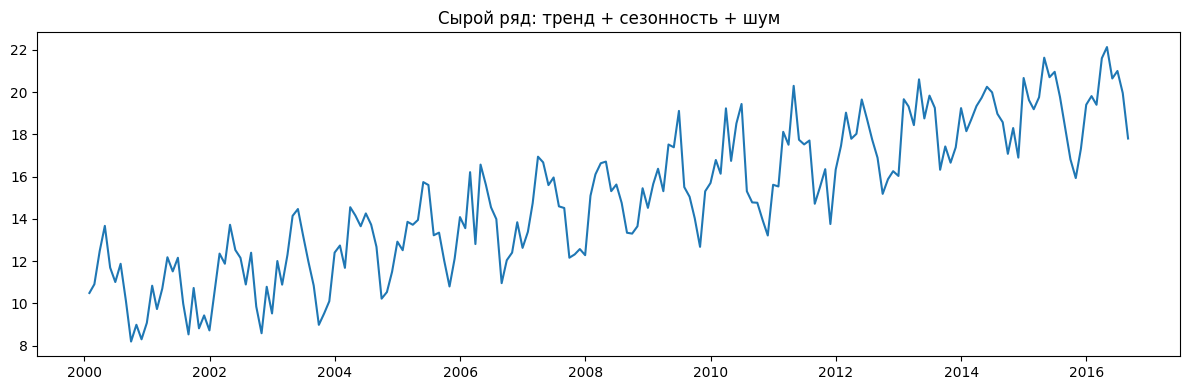

In [27]:
np.random.seed(42)
n = 200
dates = pd.date_range('2000-01-01', periods=n, freq='ME')

trend = 0.05 * np.arange(n)                    # Плавный рост уровня
season = 2.0 * np.sin(2*np.pi*np.arange(n)/12) # Годовая сезонность
noise = np.random.normal(scale=1.0, size=n)

y = 10 + trend + season + noise
s = pd.Series(y, index=dates, name='y')

plt.figure(figsize=(12,4))
plt.plot(s)
plt.title('Сырой ряд: тренд + сезонность + шум')
plt.tight_layout()
plt.show()

In [33]:
adf_p = adfuller(s.dropna(), autolag='AIC')[1]
kpss_p = kpss(s.dropna(), regression='c', nlags='auto')[1]
print(f"ADF p-value: {adf_p:.4f}  |  KPSS p-value: {kpss_p:.4f}")

ADF p-value: 0.9410  |  KPSS p-value: 0.0100


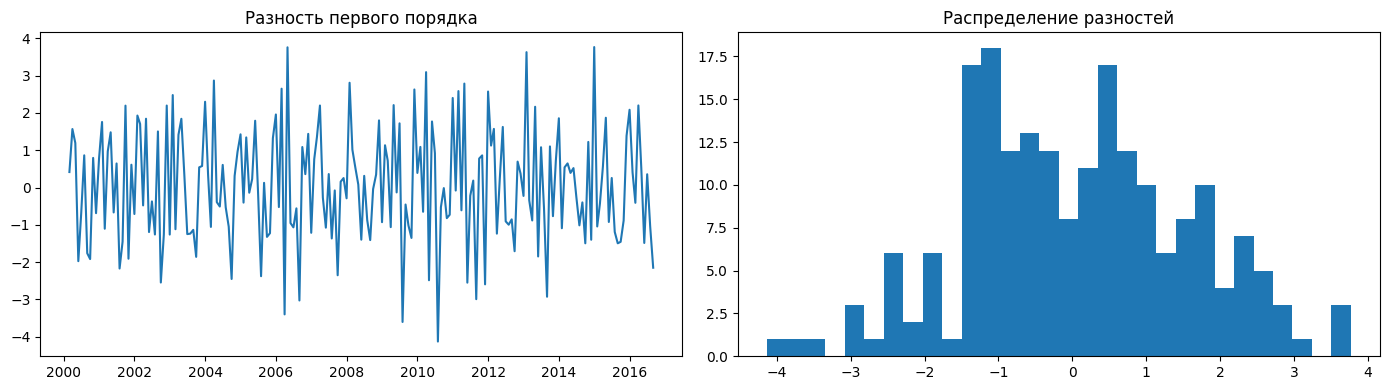

ADF p-value (diff1): 5.09346820485596e-20 | KPSS p-value (diff1): 0.1


In [34]:
d1 = s.diff().dropna()

fig, ax = plt.subplots(1,2, figsize=(14,4))
ax[0].plot(d1); ax[0].set_title('Разность первого порядка')
ax[1].hist(d1, bins=30); ax[1].set_title('Распределение разностей')
plt.tight_layout()
plt.show()

print('ADF p-value (diff1):', adfuller(d1)[1], '| KPSS p-value (diff1):', kpss(d1, regression="c", nlags="auto")[1])

In [35]:
D12 = s.diff(12).dropna()
print('ADF p-value (seasonal diff):', adfuller(D12)[1], '| KPSS p-value (seasonal diff):', kpss(D12, regression="c", nlags="auto")[1])

# Комбинация: сначала обычная, потом сезонная
d1D12 = s.diff().diff(12).dropna()
print('ADF p-value (diff1 + diff12):', adfuller(d1D12)[1], '| KPSS p-value:', kpss(d1D12, regression="c", nlags="auto")[1])

ADF p-value (seasonal diff): 1.4423246127293487e-07 | KPSS p-value (seasonal diff): 0.1
ADF p-value (diff1 + diff12): 8.976016986768224e-08 | KPSS p-value: 0.1


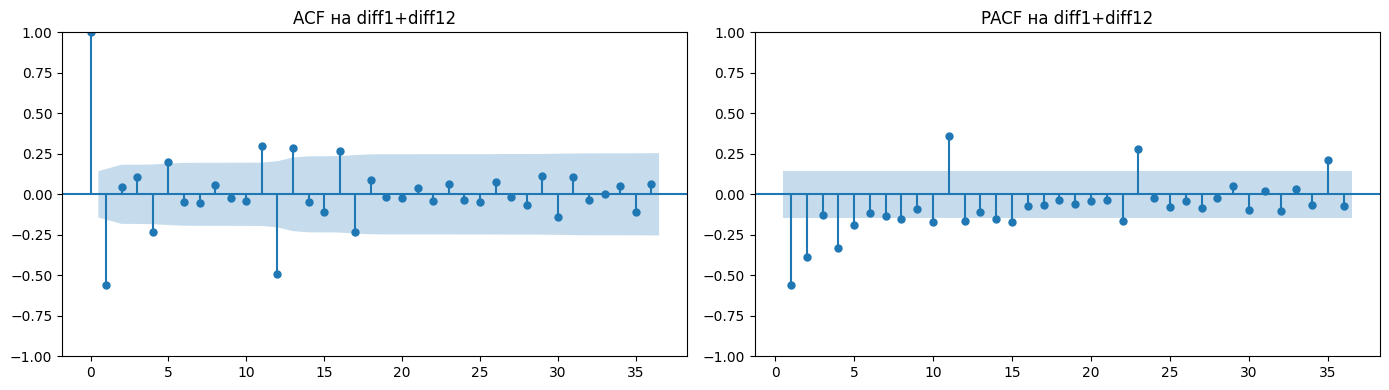

In [36]:
fig, axes = plt.subplots(1,2, figsize=(14,4))
plot_acf(d1D12, lags=36, ax=axes[0]); axes[0].set_title('ACF на diff1+diff12')
plot_pacf(d1D12, lags=36, ax=axes[1], zero=False); axes[1].set_title('PACF на diff1+diff12')
plt.tight_layout()
plt.show()

In [38]:
# Трендовая синтетика
np.random.seed(0)
n = 300
dates2 = pd.date_range('2010-01-01', periods=n, freq='D')
trend2 = 0.02*np.arange(n)
noise2 = np.random.normal(scale=0.8, size=n)
y2 = 5 + trend2 + noise2
s2 = pd.Series(y2, index=dates2, name='y')

# ARIMA(p,d,q) = ARIMA(1,1,1) как стартовая гипотеза
arima = SARIMAX(s2, order=(1,1,1), seasonal_order=(0,0,0,0), enforce_stationarity=False, enforce_invertibility=False).fit()
print(arima.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  300
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -363.112
Date:                Sun, 23 Nov 2025   AIC                            732.223
Time:                        19:43:06   BIC                            743.304
Sample:                    01-01-2010   HQIC                           736.659
                         - 10-27-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1214      0.061     -1.986      0.047      -0.241      -0.002
ma.L1         -0.8529      0.035    -24.486      0.000      -0.921      -0.785
sigma2         0.6735      0.059     11.455      0.0

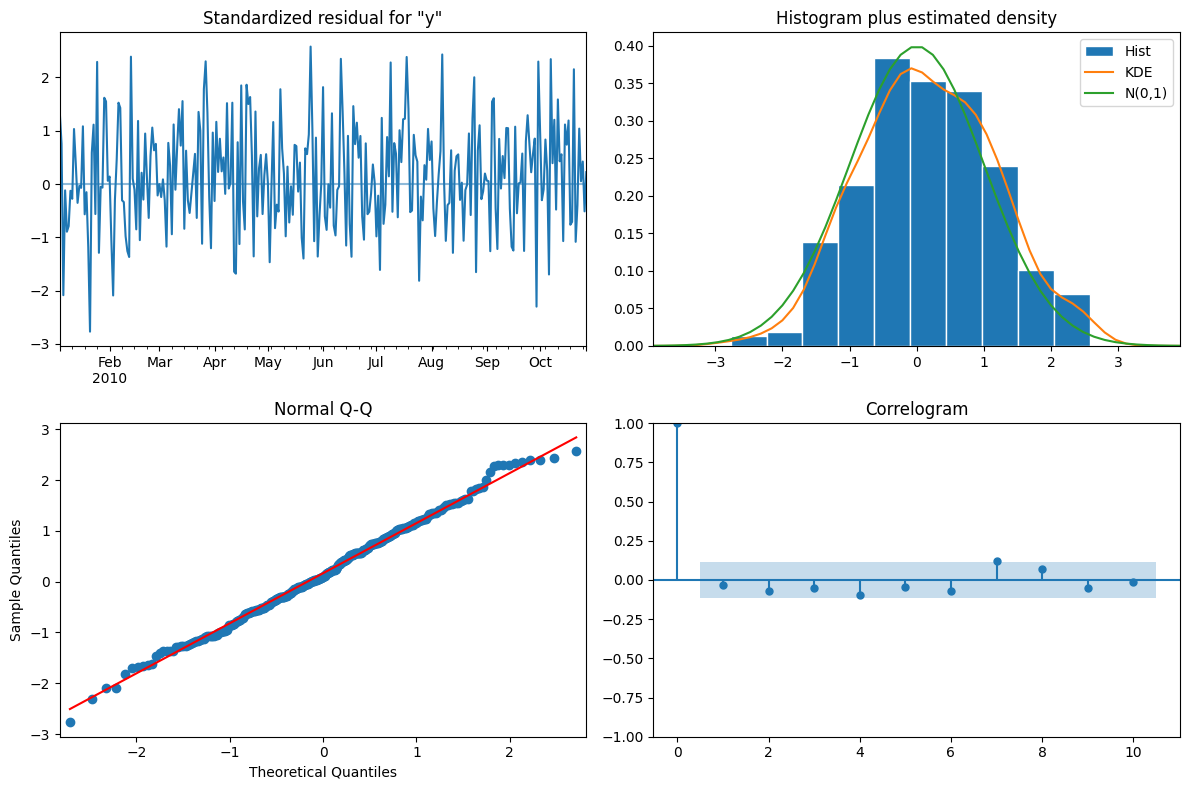

In [39]:
arima.plot_diagnostics(figsize=(12,8))
plt.tight_layout()
plt.show()

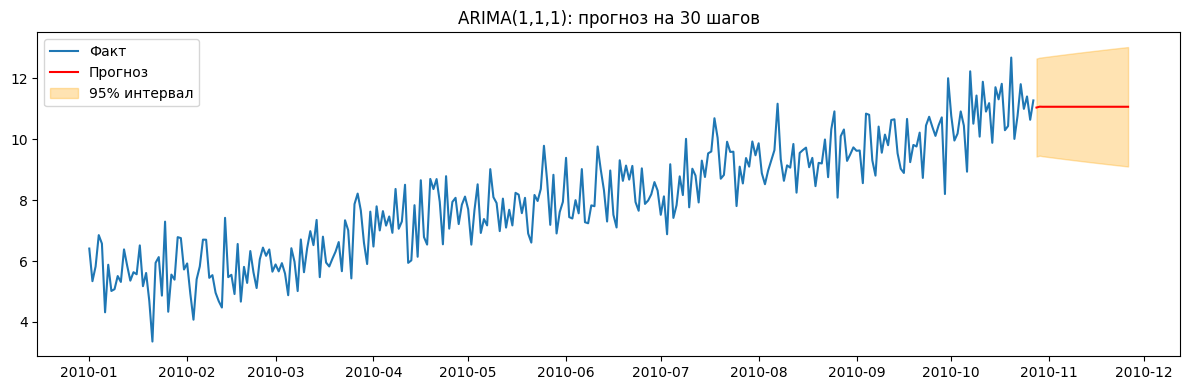

In [40]:
fc = arima.get_forecast(steps=30)
ci = fc.conf_int()

plt.figure(figsize=(12,4))
plt.plot(s2, label='Факт')
plt.plot(fc.predicted_mean.index, fc.predicted_mean, label='Прогноз', color='red')
plt.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.3, color='orange', label='95% интервал')
plt.legend()
plt.title('ARIMA(1,1,1): прогноз на 30 шагов')
plt.tight_layout()
plt.show()

### SARIMA

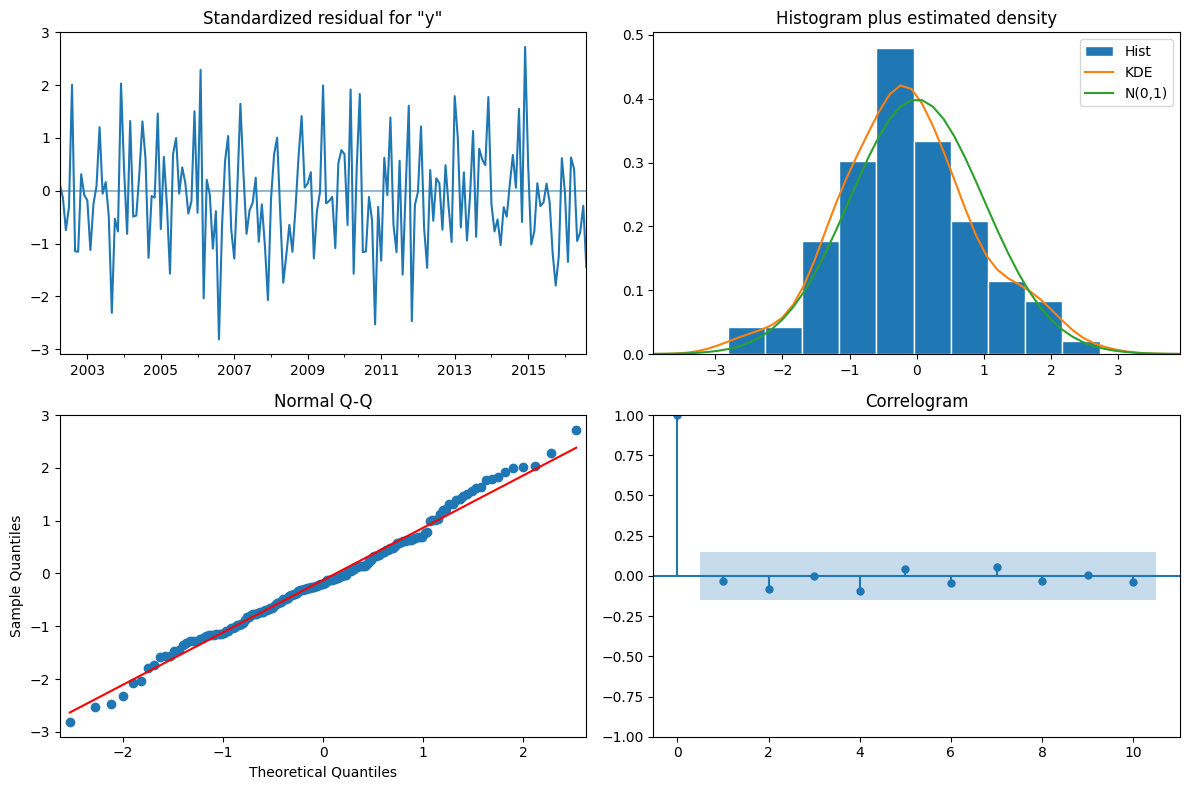

In [41]:
m = 12
sarima = SARIMAX(s, order=(1,1,1), seasonal_order=(1,1,1,m),
                 enforce_stationarity=False, enforce_invertibility=False).fit()
sarima.plot_diagnostics(figsize=(12,8))
plt.tight_layout()
plt.show()

Лучшая AIC: 487.91373291114417  order: (0, 1, 2)  seasonal: (0, 1, 1, 12)


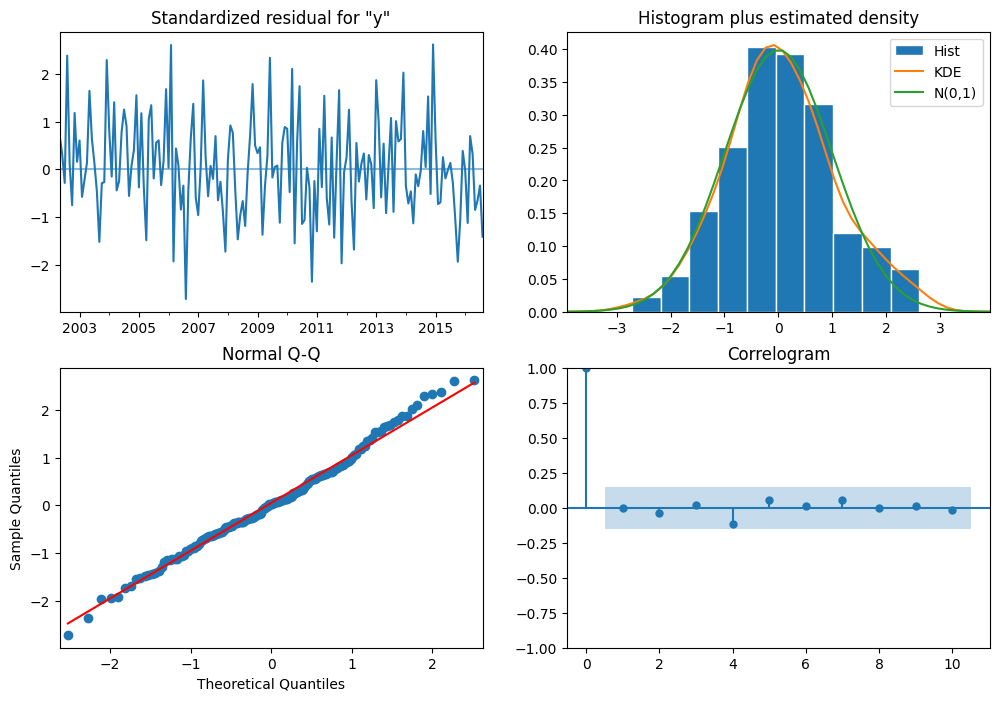

In [ ]:
def search_sarima(series, p=(0,1,2), d=(1,), q=(0,1,2),
                  P=(0,1), D=(1,), Q=(0,1), m=12, max_models=20):
    best = None
    tried = 0
    for order in itertools.product(p,d,q):
        for sorder in itertools.product(P,D,Q,[m]):
            try:
                model = SARIMAX(series, order=order, seasonal_order=sorder,
                                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                score = model.aic
                if (best is None) or (score < best[0]):
                    best = (score, order, sorder, model)
                tried += 1
                if tried >= max_models:  # Ограничим, чтобы не «сжечь» время
                    return best
            except Exception:
                continue
    return best

best = search_sarima(s, max_models=30)
print('Лучшая AIC:', best[0], ' order:', best[1], ' seasonal:', best[2])
best_model = best[3]
best_model.plot_diagnostics(figsize=(12,8))
plt.show()

fc = best_model.get_forecast(steps=24)
ci = fc.conf_int()

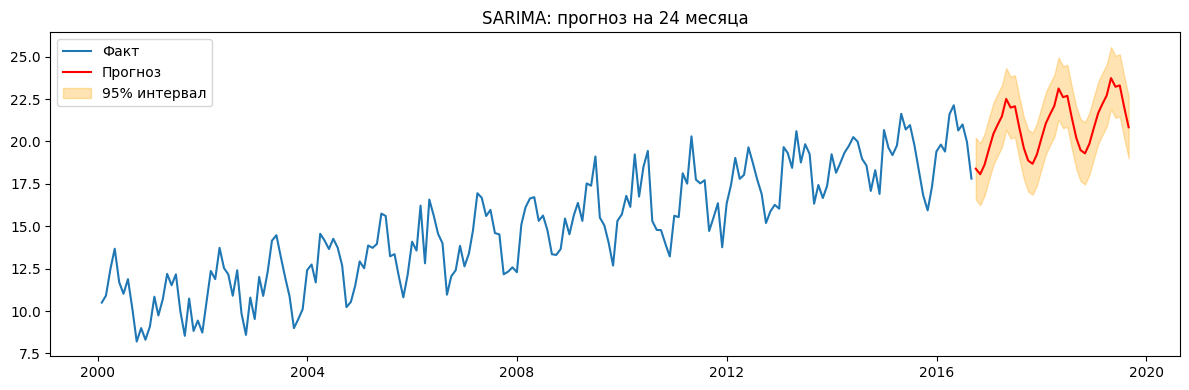

In [46]:
fc = best_model.get_forecast(steps=36)     # Прогноз на три года вперёд для месячных данных
ci = fc.conf_int()

plt.figure(figsize=(12,4))
plt.plot(s, label='Факт')
plt.plot(fc.predicted_mean.index, fc.predicted_mean, color='red', label='Прогноз')
plt.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], color='orange', alpha=0.3, label='95% интервал')
plt.legend()
plt.title('SARIMA: прогноз на 24 месяца')
plt.tight_layout()
plt.show()

### SARIMAX

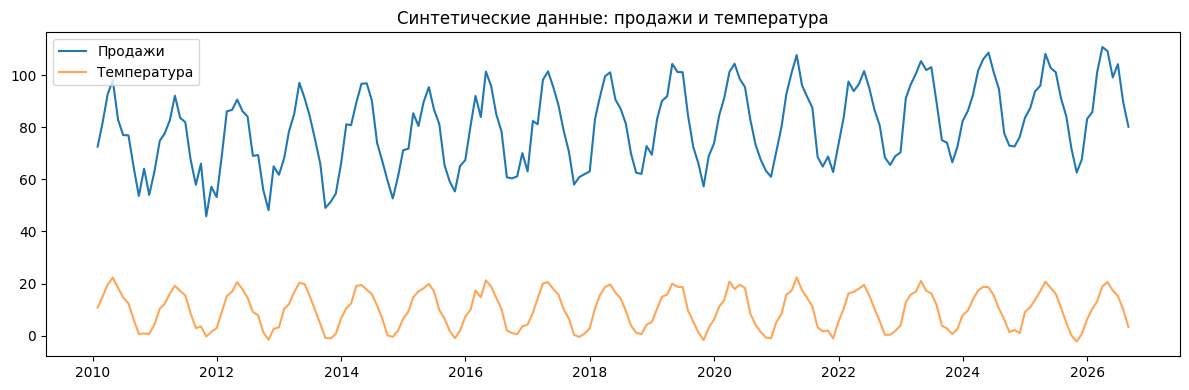

In [47]:
np.random.seed(42)
n = 200
dates = pd.date_range('2010-01-01', periods=n, freq='ME')

# Температура как внешний фактор (сезонная волна)
temp = 10 + 10*np.sin(2*np.pi*np.arange(n)/12) + np.random.normal(scale=1.5, size=n)

# Продажи: тренд + зависимость от температуры + шум
trend = 0.1*np.arange(n)
sales = 50 + trend + 2*temp + np.random.normal(scale=3, size=n)

df = pd.DataFrame({"sales": sales, "temp": temp}, index=dates)

plt.figure(figsize=(12,4))
plt.plot(df.index, df["sales"], label="Продажи")
plt.plot(df.index, df["temp"], label="Температура", alpha=0.7)
plt.legend()
plt.title("Синтетические данные: продажи и температура")
plt.tight_layout()
plt.show()

In [48]:
# SARIMAX с экзогенным фактором temp
model = SARIMAX(df["sales"], 
                order=(1,1,1), 
                seasonal_order=(1,1,1,12), 
                exog=df[["temp"]],
                enforce_stationarity=False, 
                enforce_invertibility=False).fit()

print(model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                  200
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -441.229
Date:                            Sun, 23 Nov 2025   AIC                            894.458
Time:                                    19:59:58   BIC                            913.378
Sample:                                01-31-2010   HQIC                           902.134
                                     - 08-31-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp           2.0981      0.183     11.468      0.000       1.740       2.457
ar.L1         -0.0683      0.074   

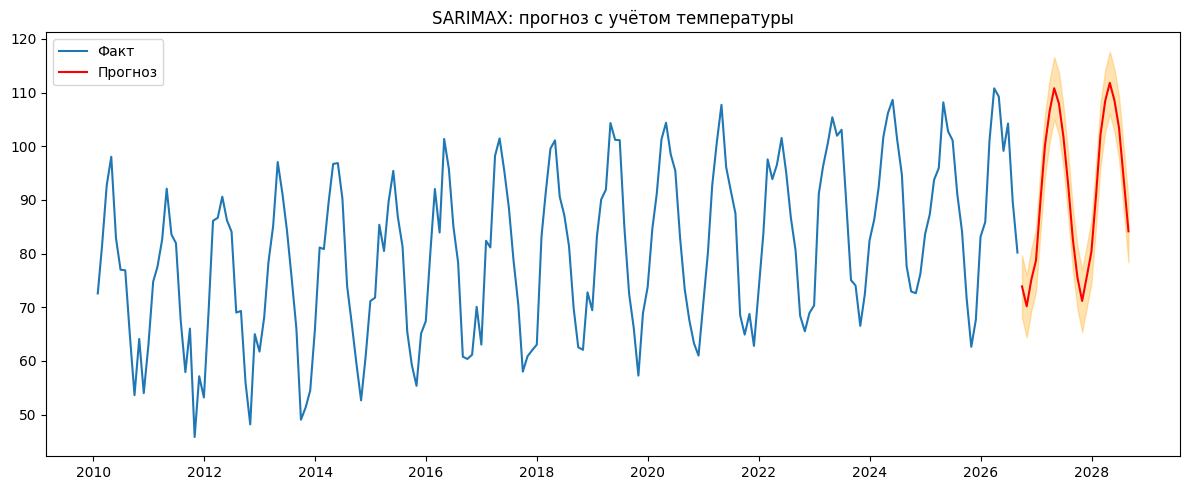

In [49]:
# Будущая температура
future_temp = 10 + 10*np.sin(2*np.pi*np.arange(n, n+24)/12)

forecast = model.get_forecast(steps=24, exog=future_temp.reshape(-1,1))
fc_mean = forecast.predicted_mean
fc_int = forecast.conf_int()

plt.figure(figsize=(12,5))
plt.plot(df.index, df["sales"], label="Факт")
plt.plot(fc_mean.index, fc_mean, color="red", label="Прогноз")
plt.fill_between(fc_int.index, fc_int.iloc[:,0], fc_int.iloc[:,1], color="orange", alpha=0.3)
plt.legend()
plt.title("SARIMAX: прогноз с учётом температуры")
plt.tight_layout()
plt.show()